In [43]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.arima.model import ARIMA
import os

# Data Loading

In [44]:

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


# EDA 

In [45]:
df = pd.read_csv(
    "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"
)
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [46]:
df.info()
print(df.isnull().sum())
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_D

In [47]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,2640.0,NaN,NaN,NaN,2020.0,3.162877,2015.0,2017.0,2020.0,2023.0,2025.0
Month,2640.0,NaN,NaN,NaN,6.5,3.452707,1.0,3.75,6.5,9.25,12.0
Region,2640,4,Europe,660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,2640,5,Model S,528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estimated_Deliveries,2640.0,NaN,NaN,NaN,9922.199621,3935.950093,48.0,7292.0,9857.0,12510.25,25704.0
Production_Units,2640.0,NaN,NaN,NaN,10655.847348,4260.600858,50.0,7828.25,10546.5,13469.0,28939.0
Avg_Price_USD,2640.0,NaN,NaN,NaN,84907.34033,20123.258036,50003.7,67726.365,85058.51,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,NaN,NaN,NaN,87.05947,20.836265,60.0,75.0,82.0,100.0,120.0
Range_km,2640.0,NaN,NaN,NaN,500.257576,120.868549,330.0,418.0,470.0,586.25,719.0
CO2_Saved_tons,2640.0,NaN,NaN,NaN,744.076989,353.221224,3.07,499.62,699.515,943.765,2548.55


In [48]:
print(df["Region"].value_counts())
print(df["Model"].value_counts())
print(df["Source_Type"].value_counts())

Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64


In [49]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
corr = df[numeric_cols].corr()

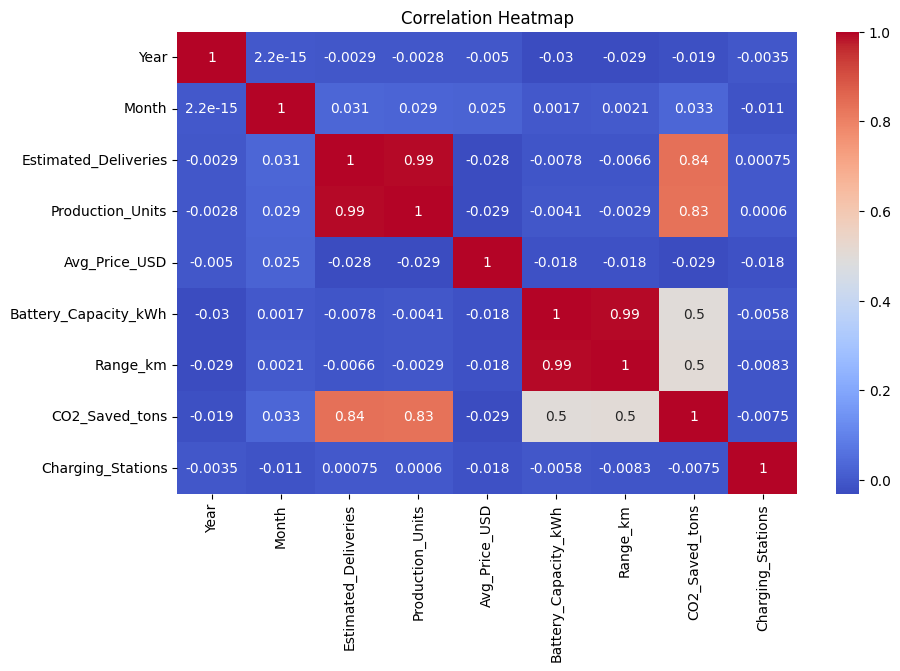

In [50]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [51]:
df["Date"] = pd.to_datetime(df[["Year", "Month"]].assign(DAY=1))
df = df.sort_values("Date")

In [52]:
monthly = df.groupby("Date").agg({
    "Estimated_Deliveries": "sum",
    "Avg_Price_USD": "mean",
    "Production_Units": "sum",
    "Charging_Stations": "mean"
}).reset_index()

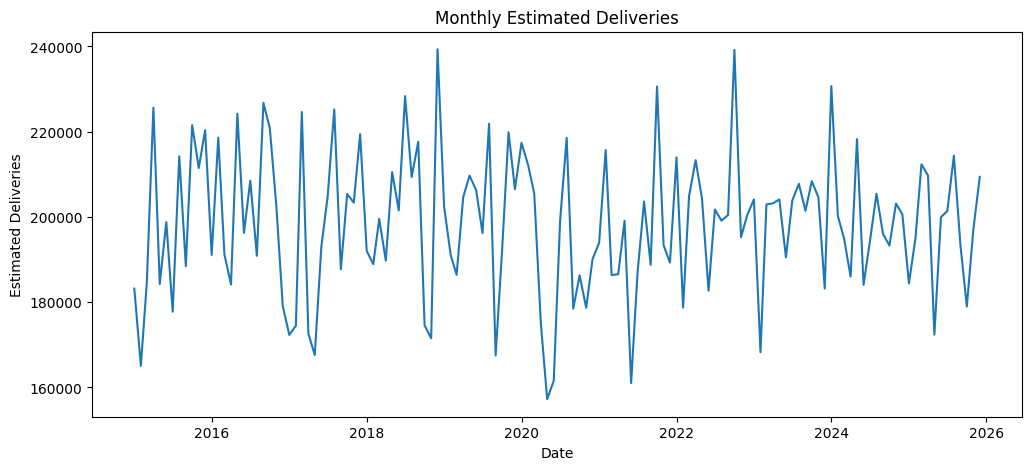

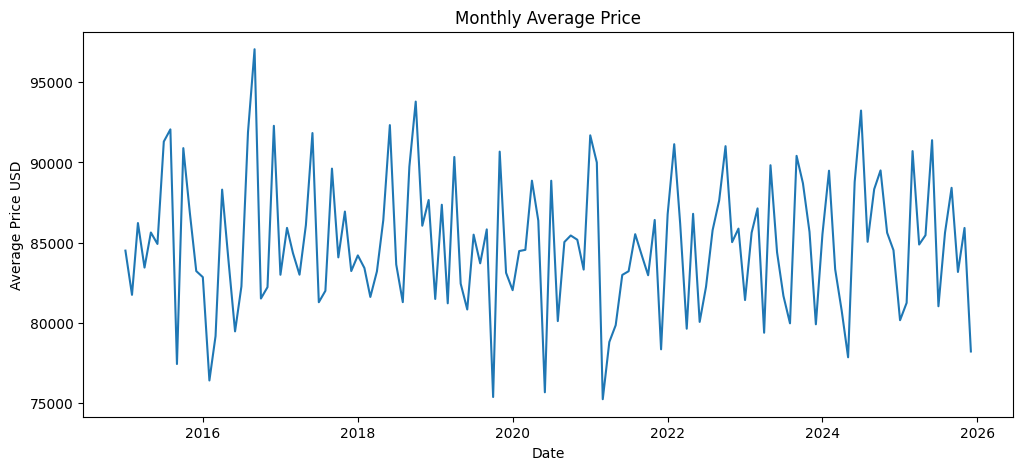

In [53]:
plt.figure(figsize=(12, 5))
plt.plot(monthly["Date"], monthly["Estimated_Deliveries"])
plt.title("Monthly Estimated Deliveries")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(monthly["Date"], monthly["Avg_Price_USD"])
plt.title("Monthly Average Price")
plt.xlabel("Date")
plt.ylabel("Average Price USD")
plt.show()

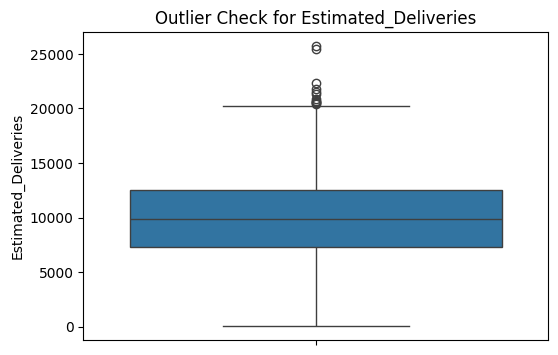

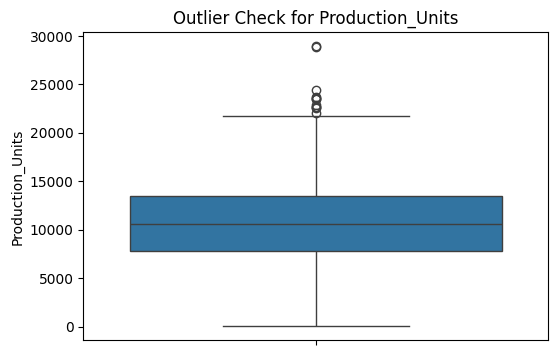

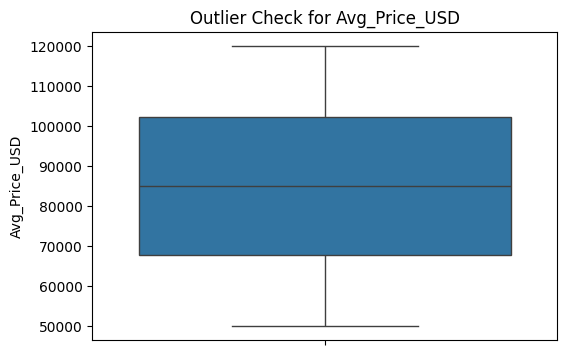

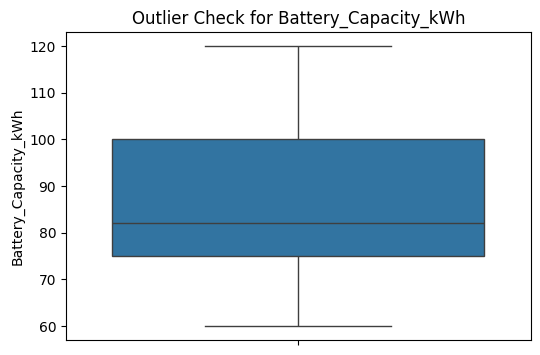

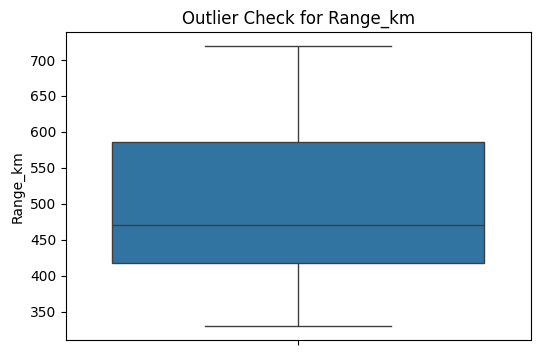

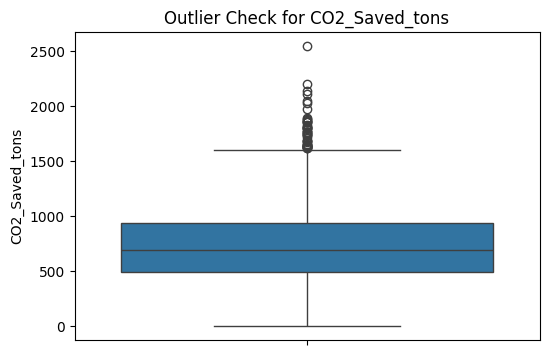

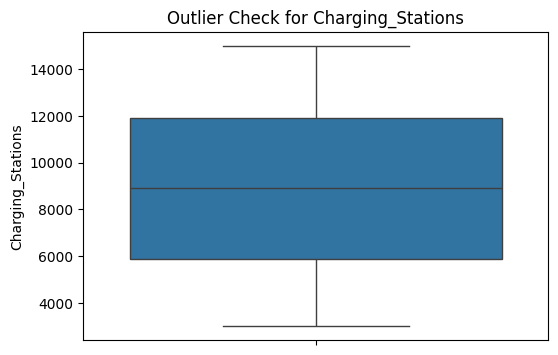

In [54]:
num_cols = [
    "Estimated_Deliveries",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations"
]

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col])
    plt.title(f"Outlier Check for {col}")
    plt.show()

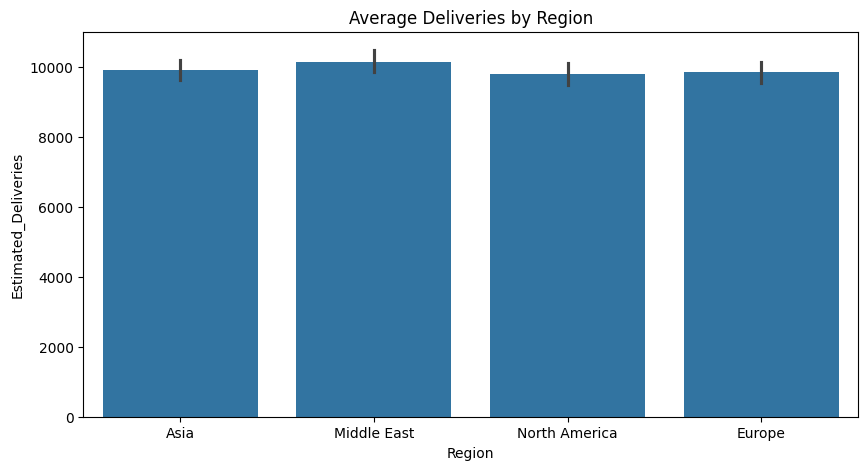

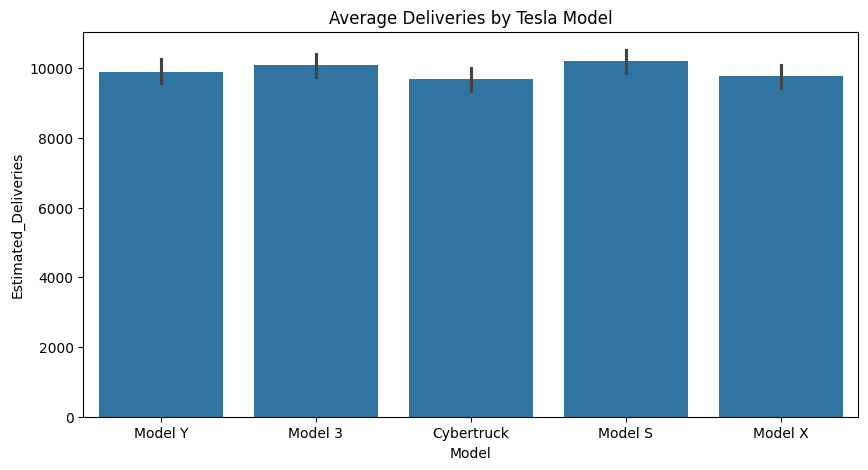

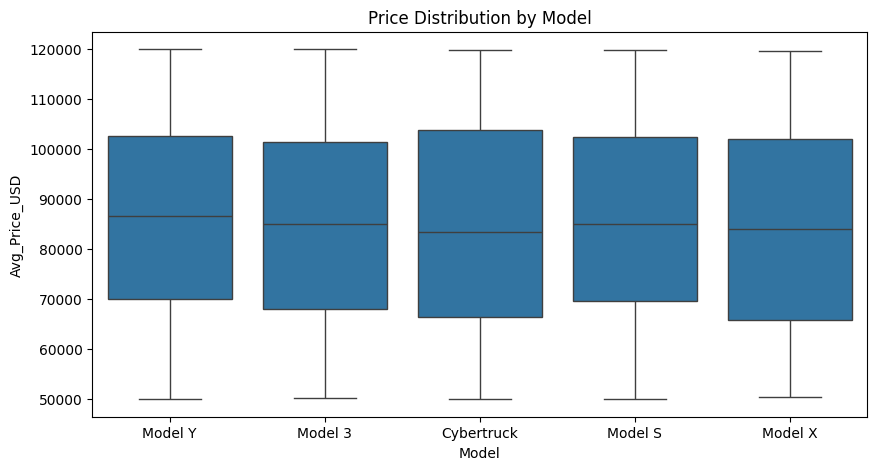

In [55]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Region", y="Estimated_Deliveries", estimator="mean")
plt.title("Average Deliveries by Region")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Model", y="Estimated_Deliveries", estimator="mean")
plt.title("Average Deliveries by Tesla Model")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Model", y="Avg_Price_USD")
plt.title("Price Distribution by Model")
plt.show()

In [56]:
monthly = df.groupby("Date").agg({
    "Estimated_Deliveries": "sum",
    "Avg_Price_USD": "mean",
    "Production_Units": "sum"
}).reset_index()

series = monthly["Estimated_Deliveries"]
adf_result = adfuller(series)
print("ADF Statistic:", adf_result[0])
print("ADF p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("ADF Result: Series is stationary")
else:
    print("ADF Result: Series is not stationary")

ADF Statistic: -8.880990349502861
ADF p-value: 1.3181396968154354e-14
ADF Result: Series is stationary


# Feature Selection


In [57]:
df = df.sort_values(["Region", "Model", "Date"])
df["Delivery_Lag_1"] = df.groupby(["Region", "Model"])["Estimated_Deliveries"].shift(1)
df["Delivery_Lag_3"] = df.groupby(["Region", "Model"])["Estimated_Deliveries"].shift(3)

In [58]:
df["Delivery_Rolling_Mean_3"] = (
    df.groupby(["Region", "Model"])["Estimated_Deliveries"]
      .transform(lambda x: x.shift(1).rolling(window=3).mean())
)

In [59]:
df = df.dropna().reset_index(drop=True)

In [60]:
X = df.drop(columns=["Estimated_Deliveries", "Date"])
Y=df["Estimated_Deliveries"]
print("Selected Features:")
print(X.columns.tolist())
print("\nShape of X:", X.shape)
print("Shape of y:", Y.shape)

Selected Features:
['Year', 'Month', 'Region', 'Model', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Delivery_Lag_1', 'Delivery_Lag_3', 'Delivery_Rolling_Mean_3']

Shape of X: (2580, 14)
Shape of y: (2580,)


In [61]:
print(df.isnull().sum())

Year                       0
Month                      0
Region                     0
Model                      0
Estimated_Deliveries       0
Production_Units           0
Avg_Price_USD              0
Battery_Capacity_kWh       0
Range_km                   0
CO2_Saved_tons             0
Source_Type                0
Charging_Stations          0
Date                       0
Delivery_Lag_1             0
Delivery_Lag_3             0
Delivery_Rolling_Mean_3    0
dtype: int64


In [62]:
print(X.isnull().sum())

Year                       0
Month                      0
Region                     0
Model                      0
Production_Units           0
Avg_Price_USD              0
Battery_Capacity_kWh       0
Range_km                   0
CO2_Saved_tons             0
Source_Type                0
Charging_Stations          0
Delivery_Lag_1             0
Delivery_Lag_3             0
Delivery_Rolling_Mean_3    0
dtype: int64


# Preprocessing


In [63]:
numeric_features = [
    "Year",
    "Month",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations",
    "Delivery_Lag_1",
    "Delivery_Lag_3",
    "Delivery_Rolling_Mean_3"
]

categorical_features = [
    "Region",
    "Model",
    "Source_Type"
]
preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),
    (OneHotEncoder(handle_unknown="ignore"), categorical_features)
)

# Model Traning


In [64]:
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [65]:
print(X_train.isnull().sum())

Year                       0
Month                      0
Region                     0
Model                      0
Production_Units           0
Avg_Price_USD              0
Battery_Capacity_kWh       0
Range_km                   0
CO2_Saved_tons             0
Source_Type                0
Charging_Stations          0
Delivery_Lag_1             0
Delivery_Lag_3             0
Delivery_Rolling_Mean_3    0
dtype: int64


In [66]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2064, 14)
X_test shape: (516, 14)
y_train shape: (2064,)
y_test shape: (516,)


In [67]:
simple_model = make_pipeline(
    preprocessor,
    LinearRegression()
)
complex_model = make_pipeline(
    preprocessor,
    RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
)

In [68]:
simple_model.fit(X_train, y_train)
complex_model.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Year', 'Month',
                                                   'Production_Units',
                                                   'Avg_Price_USD',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km', 'CO2_Saved_tons',
                                                   'Charging_Stations',
                                                   'Delivery_Lag_1',
                                                   'Delivery_Lag_3',
                                                   'Delivery_Rolling_Mean_3']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Region', 'Model',
                                                   'Source_Type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [69]:
simple_pred = simple_model.predict(X_test)
complex_pred = complex_model.predict(X_test)

In [70]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(model_name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("-" * 40)

evaluate_model("Simple Model - Linear Regression", y_test, simple_pred)
evaluate_model("Complex Model - Random Forest", y_test, complex_pred)

Simple Model - Linear Regression
MAE: 319.8817168132469
RMSE: 390.9304158101029
R2 Score: 0.9902866049927525
----------------------------------------
Complex Model - Random Forest
MAE: 319.3216085271318
RMSE: 406.5135863846497
R2 Score: 0.9894967849546494
----------------------------------------


# Hyperparameter Tunning

In [71]:
param_grid = {
    "randomforestregressor__n_estimators": [100, 200],
    "randomforestregressor__max_depth": [None, 10, 20],
    "randomforestregressor__min_samples_split": [2, 5],
    "randomforestregressor__min_samples_leaf": [1, 2]
}

In [72]:
complex_model = make_pipeline(
    preprocessor,
    RandomForestRegressor(random_state=42)
)

In [73]:
grid_search = GridSearchCV(
    estimator=complex_model,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('standardscaler',
                                                                         StandardScaler(),
                                                                         ['Year',
                                                                          'Month',
                                                                          'Production_Units',
                                                                          'Avg_Price_USD',
                                                                          'Battery_Capacity_kWh',
                                                                          'Range_km',
                                                                          'CO2_Saved_tons',
                                                                          'Charging_Stations',
                                                                          'Delivery_Lag_1',
                                                                          'Delivery_Lag_3',
                                                                          'Delivery_Rolling_Mean_3']),
                                                                        ('onehotencoder',
                                                                         OneHotEncoder(han...nknown='ignore'),
                                                                         ['Region',
                                                                          'Model',
                                                                          'Source_Type'])])),
                                       ('randomforestregressor',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'randomforestregressor__max_depth': [None, 10, 20],
                         'randomforestregressor__min_samples_leaf': [1, 2],
                         'randomforestregressor__min_samples_split': [2, 5],
                         'randomforestregressor__n_estimators': [100, 200]},
             scoring='r2')

In [74]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation R2 Score:")
print(grid_search.best_score_)

Best Parameters:
{'randomforestregressor__max_depth': None, 'randomforestregressor__min_samples_leaf': 1, 'randomforestregressor__min_samples_split': 2, 'randomforestregressor__n_estimators': 200}

Best Cross-Validation R2 Score:
0.9866664647200382


In [75]:
best_rf_model = grid_search.best_estimator_

tuned_pred = best_rf_model.predict(X_test)

evaluate_model("Tuned Random Forest", y_test, tuned_pred)

Tuned Random Forest
MAE: 318.9253585271318
RMSE: 407.1871116672251
R2 Score: 0.9894619519675708
----------------------------------------


# Forecasting


In [76]:
monthly_sales = df.groupby("Date").agg({
    "Estimated_Deliveries": "sum"
}).reset_index()

monthly_sales = monthly_sales.sort_values("Date")

series = monthly_sales.set_index("Date")["Estimated_Deliveries"]

In [77]:
import warnings
warnings.filterwarnings("ignore")

orders = [
    (1, 0, 1),
    (2, 0, 1),
    (1, 0, 2),
    (2, 0, 2),
    (3, 0, 1),
    (3, 0, 2)
]

tscv = TimeSeriesSplit(n_splits=5)

results = []

for order in orders:
    mae_scores = []
    rmse_scores = []

    for train_index, test_index in tscv.split(series):
        train_fold = series.iloc[train_index]
        test_fold = series.iloc[test_index]

        model = ARIMA(train_fold, order=order)
        model_fit = model.fit()

        forecast = model_fit.forecast(steps=len(test_fold))

        mae = mean_absolute_error(test_fold, forecast)
        rmse = np.sqrt(mean_squared_error(test_fold, forecast))

        mae_scores.append(mae)
        rmse_scores.append(rmse)

    results.append({
        "order": order,
        "Average MAE": np.mean(mae_scores),
        "Average RMSE": np.mean(rmse_scores)
    })

arima_results = pd.DataFrame(results).sort_values("Average RMSE")

print(arima_results)

       order   Average MAE  Average RMSE
2  (1, 0, 2)  12901.763941  16488.119601
0  (1, 0, 1)  12991.390530  16518.977911
3  (2, 0, 2)  13079.333210  16594.452343
1  (2, 0, 1)  13078.191273  16690.814960
4  (3, 0, 1)  13008.211630  17030.159295
5  (3, 0, 2)  13263.703329  17361.232679


In [78]:
best_order = (1, 0, 2)

train_size = int(len(series) * 0.8)

train_ts = series.iloc[:train_size]
test_ts = series.iloc[train_size:]

final_arima_model = ARIMA(train_ts, order=best_order)
final_arima_result = final_arima_model.fit()

final_forecast = final_arima_result.forecast(steps=len(test_ts))

final_mae = mean_absolute_error(test_ts, final_forecast)
final_rmse = np.sqrt(mean_squared_error(test_ts, final_forecast))

print("Final ARIMA Model:", best_order)
print("Final ARIMA MAE:", final_mae)
print("Final ARIMA RMSE:", final_rmse)

Final ARIMA Model: (1, 0, 2)
Final ARIMA MAE: 9882.666003990653
Final ARIMA RMSE: 12730.602916578313


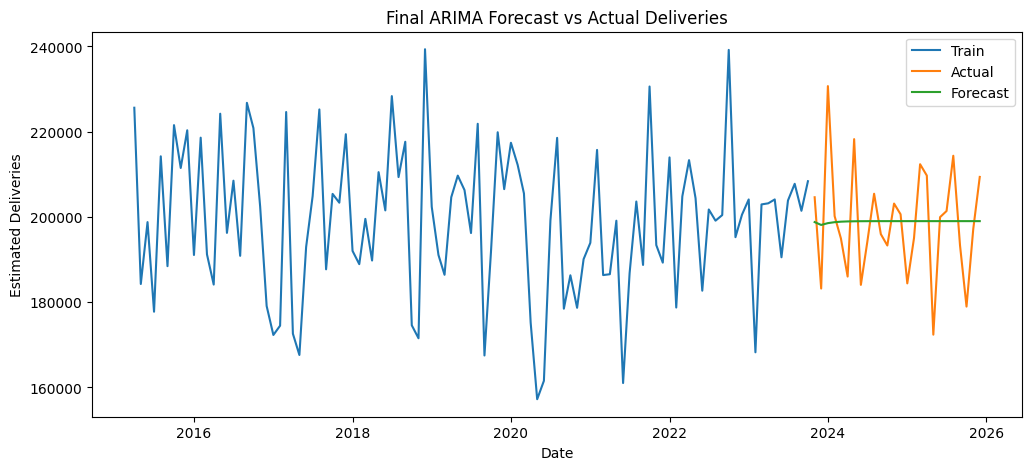

In [79]:
plt.figure(figsize=(12, 5))
plt.plot(train_ts.index, train_ts, label="Train")
plt.plot(test_ts.index, test_ts, label="Actual")
plt.plot(test_ts.index, final_forecast, label="Forecast")

plt.title("Final ARIMA Forecast vs Actual Deliveries")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.show()

The project successfully implemented an end-to-end machine learning workflow on Tesla sales and price data. The dataset was first explored through EDA, where missing values, duplicates, correlations, trends, outliers, and stationarity were checked. The correlation analysis helped identify important relationships between variables, while the ADF test confirmed that the monthly Estimated_Deliveries time series was stationary.

During feature selection and feature engineering, all relevant sales, price, production, vehicle, regional, and charging infrastructure features were used. Additional lag and rolling mean features were created to capture historical delivery patterns. These engineered features significantly improved the regression model performance.

Two regression models were compared: Linear Regression as a simple model and Random Forest Regressor as a complex model. Both models performed very well after adding lag and rolling features. Linear Regression achieved the best overall performance with an R2 score of approximately 0.99, showing that the selected and engineered features were highly effective for predicting Estimated_Deliveries.

Hyperparameter tuning was performed on the Random Forest model using GridSearchCV. This helped test different combinations of model parameters and select the best-performing version of the complex model. Although tuning improved model selection, Linear Regression still remained slightly better overall based on the evaluation metrics.

For time series forecasting, the monthly delivery data was aggregated and tested for stationarity using the ADF test. Since the series was stationary, ARIMA models were applied without differencing. TimeSeriesSplit cross-validation was used to evaluate multiple ARIMA orders while preserving chronological order. ARIMA(1, 0, 2) produced the best results among the tested configurations, with the lowest average MAE and RMSE.

However, the ARIMA forecast remained relatively smooth and close to the average delivery level. This showed that ARIMA was able to capture the general level of deliveries but struggled to capture sharp monthly fluctuations. This limitation is expected because ARIMA is a univariate model and does not use external features such as production units, price, region, model, or charging station count.

Overall, the regression-based machine learning model with engineered lag and rolling features performed best for delivery prediction, while ARIMA provided a useful baseline for statistical time series forecasting. The project demonstrates the complete process of EDA, preprocessing, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.